In [1]:
import pandas as pd

# Teams
teams_original = pd.read_csv('/data/workspace_files/teams.csv')

# Coaches
coaches_original = pd.read_csv('/data/workspace_files/coaches.csv')

# Player for each team
players_for_team_original = pd.read_csv('/data/workspace_files/players_teams.csv')

# Players in General
players_original = pd.read_csv('/data/workspace_files/players.csv')

# Series Post
series_post_original = pd.read_csv('/data/workspace_files/series_post.csv')

# Teams Post
teams_post_original = pd.read_csv('/data/workspace_files/teams_post.csv')

# Teams in General
teams_original = pd.read_csv('/data/workspace_files/teams.csv')

# Final one dataframe to be used!
final = pd.DataFrame()

print(players_for_team_original.head())

     playerID  year  stint tmID  lgID  GP  GS  minutes  points  oRebounds  \
0  abrossv01w     2      0  MIN  WNBA  26  23      846     343         43   
1  abrossv01w     3      0  MIN  WNBA  27  27      805     314         45   
2  abrossv01w     4      0  MIN  WNBA  30  25      792     318         44   
3  abrossv01w     5      0  MIN  WNBA  22  11      462     146         17   
4  abrossv01w     6      0  MIN  WNBA  31  31      777     304         29   

   ...  PostBlocks  PostTurnovers  PostPF  PostfgAttempted  PostfgMade  \
0  ...           0              0       0                0           0   
1  ...           0              0       0                0           0   
2  ...           1              8       8               22           6   
3  ...           2              3       7               23           8   
4  ...           0              0       0                0           0   

   PostftAttempted  PostftMade  PostthreeAttempted  PostthreeMade  PostDQ  
0               

In [2]:
teams = teams_original.copy()

#Start by just associate team with playoff access in year 2

#Sort by each team and ascending year
teams = teams.sort_values(['franchID','year'])
#Associate playoff access in next year to previous year stats
teams['playoffNextYear'] = teams['playoff'].shift(-1)
#Remove playoff access info for last line of each team, as next line (that got shifted up) belongs to another team
teams.loc[teams['franchID'] != teams['franchID'].shift(-1),'playoffNextYear'] = None

In [3]:
#Define features and label
features = ['rank']
label = 'playoffNextYear'

#Train data -> 5 first seasons (since the beggining of this dataset)
train_data = teams[teams['year']<=5].dropna(subset=[label])
#Test data -> 6 and 7 seasons
test_data = teams[teams['year'].isin([6,7])].dropna(subset=[label])

print(train_data[features].head())
print(test_data[features].head())
print(train_data[label].head())
print(test_data[label].head())

x_train, y_train = train_data[features], train_data[label]
x_test, y_test = test_data[features], test_data[label]

   rank
2     8
3     4
4     2
5     2
6     5
    rank
7      6
9      7
19     1
20     1
29     4
2    Y
3    Y
4    Y
5    N
6    N
Name: playoffNextYear, dtype: object
7     N
9     N
19    Y
20    Y
29    Y
Name: playoffNextYear, dtype: object


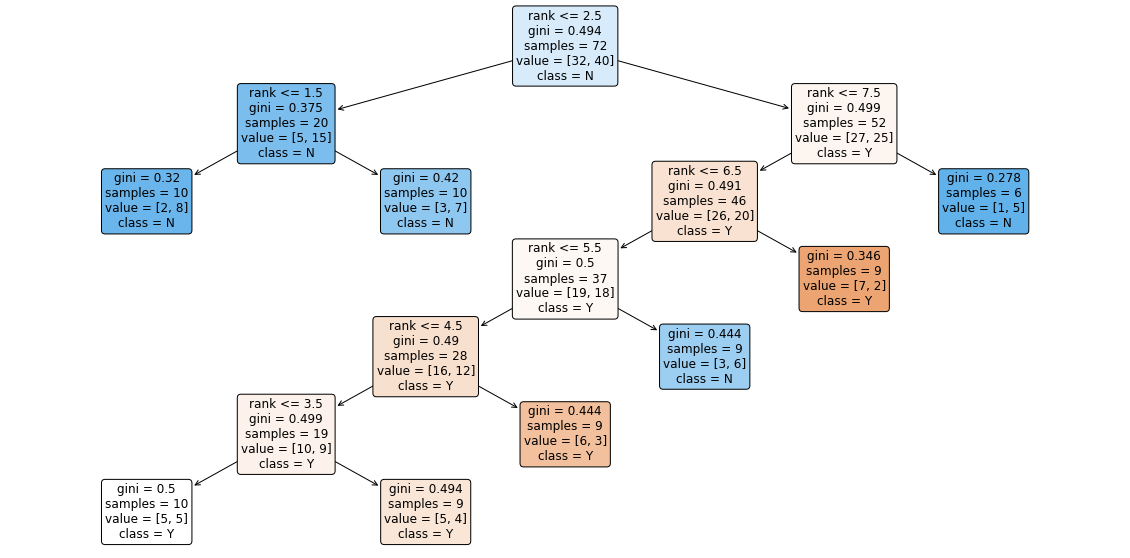

In [4]:
# Import necessary libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier()

# Train the model
clf.fit(x_train, y_train)

# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=features, class_names=train_data[label].unique(), rounded=True, fontsize=12)
plt.show()

In [5]:
# Predict on the test data
y_pred = clf.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Print a detailed classification report
print(classification_report(y_test, y_pred))

Accuracy: 57.69%
              precision    recall  f1-score   support

           N       0.47      0.70      0.56        10
           Y       0.73      0.50      0.59        16

    accuracy                           0.58        26
   macro avg       0.60      0.60      0.58        26
weighted avg       0.63      0.58      0.58        26



# Analysed Columns
## Teams

- rank
- nos playoffs, ñ passou zero, L 0.25, W 1
- o_pts
- d_pts
- % games won

## Awards_players
- Associate awards to players with respective years

## Coaches
- Win/Loss ratio of the trainer's career
- Post_win/Post_loss ratio of the trainer's playoffs

## Players
- Player height
- Player position to associate to each player form

## Series_post
- Useless table

## Teams_post
- Win/Loss ratio for the team playoffs

## Players_teams

- percentile rebounds
- percentile of avg (fgMade/fgAttempted)
- percentile rebounds
- percentile of avg (GS/GP) 
- percentile of avg (ftMade/ftAttempted)
- percentile of avg (threeMade/threeAtempted)
- percentile of assists
- percentile of steals
- percentile of PF
- percentile of blocks
- percentile of points scored
(Missing TurnOvers)

use percentile of minutes to multiplicate by the feature (player's influence).



### Player's Perfomance

"forma" depende da posição - pode ser defesas para defesas, pontos para atacantes etc.

- avg (jogador passou aos playoffs as últimas 3 épocas) todos os jogadores que continuam na equipa esta época

- avg ("forma" jogador época passada) todos os jogadores que continuam na equipa esta época

- avg (melhoria "forma" jogador 3 últimas épocas) todos os jogadores que continuam na equipa esta época

- avg ("forma" all time) todos os jogadores que continuam na equipa esta época

### Performance dependant on position

#### Guards
Guards (typically point guards and shooting guards) focus on ball handling, shooting, and playmaking. They are often the leaders in assists and steals but generally have fewer rebounds and blocks than forwards and centers.

- **Key Statistics for Guards:**
  - **Assists:** Guards are often primary ball-handlers and playmakers.
  - **Steals:** Guards are usually quick and more likely to intercept passes.
  - **Three Points:** Shooting guards often take and make more 3-pointers.
  - **Field Goals:** Guards often take a large number of shots.
  - **Free Throws:** Guards tend to drive to the basket, drawing fouls.

#### Forwards
Forwards (small forwards and power forwards) are versatile players who contribute to both offense and defense. They often contribute to scoring and rebounding but also play a role in blocking shots.

- **Key Statistics for Forwards:**
  - **Points Scored:** Forwards tend to score from both inside and outside.
  - **Field Goals:** Forward's mid-range and inside game lead to higher field goal attempts.
  - **Rebounds (Offensive and Defensive):** Forwards are often key rebounders.
  - **Steals and Blocks:** They contribute to both stats, but usually less than centers in blocks and more than guards in steals.
  - **Personal Fouls:** Forwards often play physical defense, leading to fouls.

### Centers
Centers are typically the tallest players on the court and are known for their presence near the basket. They excel in rebounding, blocking shots, and scoring from close range.

- **Key Statistics for Centers:**
  - **Rebounds (Offensive and Defensive):** Centers are usually leaders in rebounds.
  - **Blocks:** Centers dominate this category due to their size and positioning near the rim.
  - **Points Scored:** Often from inside the paint.
  - **Field Goals:** Many of their shots are from close range, so they tend to have a high FG percentage.
  - **Personal Fouls:** As centers play near the basket, they tend to commit more fouls.

#### Summarized Breakdown by Position:

| Statistic              | Guard                  | Forward             | Center              |
|------------------------|------------------------|---------------------|---------------------|
| **Offensive Rebounds**  | Low                    | Medium              | High                |
| **Defensive Rebounds**  | Low                    | Medium              | High                |
| **Rebounds**            | Low                    | Medium              | High                |
| **Field Goals**         | High                   | High                | Medium to High      |
| **Free Throws**         | High                   | Medium              | Medium              |
| **Three Points**        | High                   | Medium              | Low                 |
| **Assists**             | High                   | Medium              | Low                 |
| **Steals**              | High                   | Medium              | Low                 |
| **Personal Fouls**      | Low                    | Medium              | High                |
| **Blocks**              | Low                    | Medium              | High                |
| **Points Scored**       | High                   | High                | Medium to High      |